In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

2026-03-24 07:35:19.261072: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 07:35:19.284273: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-24 07:35:19.284290: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-24 07:35:19.284907: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-24 07:35:19.288790: I tensorflow/core/platform/cpu_feature_guar

In [2]:

vocab_size = 10000

(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

print("Training samples:", len(train_data))
print("Test samples:", len(test_data))


Training samples: 25000
Test samples: 25000


In [3]:
print(train_data[0][:20])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]


In [4]:
word_index = tf.keras.datasets.imdb.get_word_index()
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [5]:
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index

{34704: 'fawn',
 52009: 'tsukino',
 52010: 'nunnery',
 16819: 'sonja',
 63954: 'vani',
 1411: 'woods',
 16118: 'spiders',
 2348: 'hanging',
 2292: 'woody',
 52011: 'trawling',
 52012: "hold's",
 11310: 'comically',
 40833: 'localized',
 30571: 'disobeying',
 52013: "'royale",
 40834: "harpo's",
 52014: 'canet',
 19316: 'aileen',
 52015: 'acurately',
 52016: "diplomat's",
 25245: 'rickman',
 6749: 'arranged',
 52017: 'rumbustious',
 52018: 'familiarness',
 52019: "spider'",
 68807: 'hahahah',
 52020: "wood'",
 40836: 'transvestism',
 34705: "hangin'",
 2341: 'bringing',
 40837: 'seamier',
 34706: 'wooded',
 52021: 'bravora',
 16820: 'grueling',
 1639: 'wooden',
 16821: 'wednesday',
 52022: "'prix",
 34707: 'altagracia',
 52023: 'circuitry',
 11588: 'crotch',
 57769: 'busybody',
 52024: "tart'n'tangy",
 14132: 'burgade',
 52026: 'thrace',
 11041: "tom's",
 52028: 'snuggles',
 29117: 'francesco',
 52030: 'complainers',
 52128: 'templarios',
 40838: '272',
 52031: '273',
 52133: 'zaniacs',

In [6]:
reverse_word_index.get(52393)

'sequals'

In [7]:
for i in range(20):
    print(reverse_word_index.get(i))

None
None
None
None
the
and
a
of
to
is
br
in
it
i
this
that
was
as
for
with


In [8]:



reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(text):
    return " ".join([reverse_word_index.get(i, "?") for i in text])

print(decode_review(train_data[10]))


<START> french horror cinema has seen something of a revival over the last couple of years with great films such as inside and <UNK> romance <UNK> on to the scene <UNK> <UNK> the revival just slightly but stands head and shoulders over most modern horror titles and is surely one of the best french horror films ever made <UNK> was obviously shot on a low budget but this is made up for in far more ways than one by the originality of the film and this in turn is <UNK> by the excellent writing and acting that ensure the film is a winner the plot focuses on two main ideas prison and black magic the central character is a man named <UNK> sent to prison for fraud he is put in a cell with three others the quietly insane <UNK> body building <UNK> marcus and his retarded boyfriend daisy after a short while in the cell together they stumble upon a hiding place in the wall that contains an old <UNK> after <UNK> part of it they soon realise its magical powers and realise they may be able to use it 

In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 256

train_data = pad_sequences(
    train_data,
    value=0,
    padding="post",
    maxlen=max_length
)

test_data = pad_sequences(
    test_data,
    value=0,
    padding="post",
    maxlen=max_length
)

In [10]:
train_data[0]

array([   1,   14,   22,   16,   43,  530,  973, 1622, 1385,   65,  458,
       4468,   66, 3941,    4,  173,   36,  256,    5,   25,  100,   43,
        838,  112,   50,  670,    2,    9,   35,  480,  284,    5,  150,
          4,  172,  112,  167,    2,  336,  385,   39,    4,  172, 4536,
       1111,   17,  546,   38,   13,  447,    4,  192,   50,   16,    6,
        147, 2025,   19,   14,   22,    4, 1920, 4613,  469,    4,   22,
         71,   87,   12,   16,   43,  530,   38,   76,   15,   13, 1247,
          4,   22,   17,  515,   17,   12,   16,  626,   18,    2,    5,
         62,  386,   12,    8,  316,    8,  106,    5,    4, 2223, 5244,
         16,  480,   66, 3785,   33,    4,  130,   12,   16,   38,  619,
          5,   25,  124,   51,   36,  135,   48,   25, 1415,   33,    6,
         22,   12,  215,   28,   77,   52,    5,   14,  407,   16,   82,
          2,    8,    4,  107,  117, 5952,   15,  256,    4,    2,    7,
       3766,    5,  723,   36,   71,   43,  530,  4

In [11]:
test_data[0]

array([   1,  591,  202,   14,   31,    6,  717,   10,   10,    2,    2,
          5,    4,  360,    7,    4,  177, 5760,  394,  354,    4,  123,
          9, 1035, 1035, 1035,   10,   10,   13,   92,  124,   89,  488,
       7944,  100,   28, 1668,   14,   31,   23,   27, 7479,   29,  220,
        468,    8,  124,   14,  286,  170,    8,  157,   46,    5,   27,
        239,   16,  179,    2,   38,   32,   25, 7944,  451,  202,   14,
          6,  717,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [12]:
import pandas as pd

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [13]:

decode_review(train_data[0])

"<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wh

In [14]:
pd.DataFrame(train_data)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255
0,1,14,22,16,43,530,973,1622,1385,65,458,4468,66,3941,4,173,36,256,5,25,100,43,838,112,50,670,2,9,35,480,284,5,150,4,172,112,167,2,336,385,39,4,172,4536,1111,17,546,38,13,447,4,192,50,16,6,147,2025,19,14,22,4,1920,4613,469,4,22,71,87,12,16,43,530,38,76,15,13,1247,4,22,17,515,17,12,16,626,18,2,5,62,386,12,8,316,8,106,5,4,2223,5244,16,480,66,3785,33,4,130,12,16,38,619,5,25,124,51,36,135,48,25,1415,33,6,22,12,215,28,77,52,5,14,407,16,82,2,8,4,107,117,5952,15,256,4,2,7,3766,5,723,36,71,43,530,476,26,400,317,46,7,4,2,1029,13,104,88,4,381,15,297,98,32,2071,56,26,141,6,194,7486,18,4,226,22,21,134,476,26,480,5,144,30,5535,18,51,36,28,224,92,25,104,4,226,65,16,38,1334,88,12,16,283,5,16,4472,113,103,32,15,16,5345,19,178,32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,194,1153,194,8255,78,228,5,6,1463,4369,5012,134,26,4,715,8,118,1634,14,394,20,13,119,954,189,102,5,207,110,3103,21,14,69,188,8,30,23,7,4,249,126,93,4,114,9,2300,1523,5,647,4,116,9,35,8163,4,229,9,340,1322,4,118,9,4,130,4901,19,4,1002,5,89,29,952,46,37,4,455,9,45,43,38,1543,1905,398,4,1649,26,6853,5,163,11,3215,2,4,1153,9,194,775,7,8255,2,349,2637,148,605,2,8003,15,123,125,68,2,6853,15,349,165,4362,98,5,4,228,9,43,2,1157,15,299,120,5,120,174,11,220,175,136,50,9,4373,228,8255,5,2,656,245,2350,5,4,9837,131,152,491,18,2,32,7464,1212,14,9,6,371,78,22,625,64,1382,9,8,168,145,23,4,1690,15,16,4,1355,5,28,6,52,154,462,33,89,78,285,16,145,95,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,14,47,8,30,31,7,4,249,108,7,4,5974,54,61,369,13,71,149,14,22,112,4,2401,311,12,16,3711,33,75,43,1829,296,4,86,320,35,534,19,263,4821,1301,4,1873,33,89,78,12,66,16,4,360,7,4,58,316,334,11,4,1716,43,645,662,8,257,85,1200,42,1228,2578,83,68,3912,15,36,165,1539,278,36,69,2,780,8,106,14,6905,1338,18,6,22,12,215,28,610,40,6,87,326,23,2300,21,23,22,12,272,40,57,31,11,4,22,47,6,2307,51,9,170,23,595,116,595,1352,13,191,79,638,89,2,14,9,8,106,607,624,35,534,6,227,7,129,113,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1784,86,1117,8,3261,46,11,2,21,29,9,2841,23,4,1010,2,793,6,2,1386,1830,10,10,246,50,9,6,2750,1944,746,90,29,2,8,124,4,882,4,882,496,27,2,2213,537,121,127,1219,130,5,29,494,8,124,4,882,496,4,341,7,27,846,10,10,29,9,1906,8,97,6,236,2,1311,8,4,2,7,31,7,2,91,2,3987,70,4,882,30,579,42,9,12,32,11,537,10,10,11,14,65,44,537,75,2,1775,3353,2,1846,4,2,7,154,5,4,518,53,2,2,7,3211,882,11,399,38,75,257,3807,19,2,17,29,456,4,65,7,27,205,113,10,10,2,4,2,2,9,242,4,91,1202,2,5,2070,307,22,7,5168,126,93,40,2,13,188,1076,3222,19,4,2,7,2348,537,23,53,537,21,82,40,2,13,2,14,280,13,219,4,2,431,758,859,4,953,1052,2,7,5991,5,94,40,25,238,60,2,4,2,804,2,7,4,9941,132,8,67,6,22,15,9,283,8,5168,14,31,9,242,955,48,25,279,2,23,12,1685,195,25,238,60,796,2,4,671,7,2804,5,4,559,154,888,7,726,50,26,49,7008,15,566,30,579,21,64,

In [15]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, GlobalAveragePooling1D

In [16]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=16),
    GlobalAveragePooling1D(),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 16)          160000    
                                                                 
 global_average_pooling1d (  (None, 16)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 16)                272       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 160289 (626.13 KB)
Trainable params: 160289 (626.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-03-24 07:35:22.421361: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-24 07:35:22.443247: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-24 07:35:22.445513: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [17]:
history = model.fit(
    train_data,
    train_labels,
    epochs=10,
    batch_size=512,
    validation_split=0.2
)


Epoch 1/10


2026-03-24 07:35:23.352911: I external/local_xla/xla/service/service.cc:168] XLA service 0x7e1f55d59ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-24 07:35:23.352929: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-03-24 07:35:23.356269: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-24 07:35:23.368272: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8900
I0000 00:00:1774337723.425238 1366164 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


40/40 [==============================] - 4s 79ms/step - loss: 0.6913 - accuracy: 0.5541 - val_loss: 0.6879 - val_accuracy: 0.6628
Epoch 2/10
40/40 [==============================] - 3s 73ms/step - loss: 0.6818 - accuracy: 0.7006 - val_loss: 0.6720 - val_accuracy: 0.7418
Epoch 3/10
40/40 [==============================] - 2s 60ms/step - loss: 0.6588 - accuracy: 0.7554 - val_loss: 0.6402 - val_accuracy: 0.7740
Epoch 4/10
40/40 [==============================] - 2s 53ms/step - loss: 0.6187 - accuracy: 0.7872 - val_loss: 0.5941 - val_accuracy: 0.7938
Epoch 5/10
40/40 [==============================] - 2s 49ms/step - loss: 0.5656 - accuracy: 0.8146 - val_loss: 0.5401 - val_accuracy: 0.8136
Epoch 6/10
40/40 [==============================] - 2s 54ms/step - loss: 0.5067 - accuracy: 0.8408 - val_loss: 0.4869 - val_accuracy: 0.8274
Epoch 7/10
40/40 [==============================] - 1s 36ms/step - loss: 0.4502 - accuracy: 0.8576 - val_loss: 0.4405 - val_accuracy: 0.8442
Epoch 8/10
40/40 [======

In [18]:
loss, accuracy = model.evaluate(test_data, test_labels)

print("Test Accuracy:", accuracy)

782/782 [==============================] - 1s 648us/step - loss: 0.3628 - accuracy: 0.8621
Test Accuracy: 0.8620799779891968


In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [20]:
predictions = model.predict(test_data)

pred_labels = (predictions > 0.5).astype(int).flatten()



782/782 [==============================] - 0s 455us/step


In [21]:

print("\nClassification Report:\n")

print(classification_report(test_labels, pred_labels))



Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.88      0.86     12500
           1       0.87      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



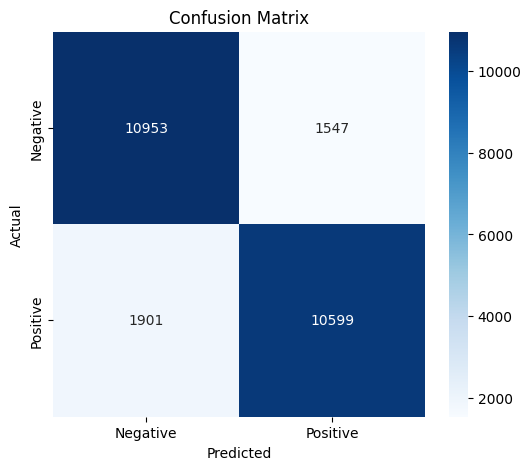

In [22]:
cm = confusion_matrix(test_labels, pred_labels)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

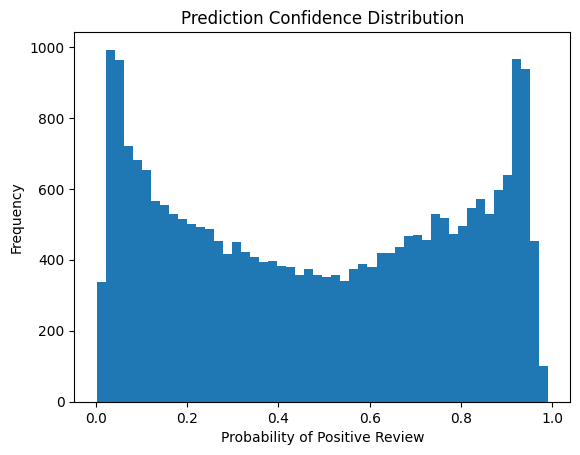

In [23]:
plt.hist(predictions, bins=50)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Probability of Positive Review")
plt.ylabel("Frequency")

plt.show()


In [24]:
word_index = tf.keras.datasets.imdb.get_word_index()

reverse_word_index = {value + 3: key for key, value in word_index.items()}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"


def decode_review(text):
    return " ".join([reverse_word_index.get(i, "?") for i in text])



In [25]:
misclassified = np.where(pred_labels != test_labels)[0]

print("\nTotal misclassified:", len(misclassified))


print("\nShowing 5 misclassified reviews:\n")

for i in misclassified[:5]:

    print("Actual:", test_labels[i])
    print("Predicted:", pred_labels[i])
    print("Confidence:", predictions[i][0])

    print("\nReview text:\n")

    print(decode_review(test_data[i]))

    print("\n" + "-"*80 + "\n")


Total misclassified: 3448

Showing 5 misclassified reviews:

Actual: 1
Predicted: 0
Confidence: 0.40321538

Review text:

<START> i'm absolutely disgusted this movie isn't being sold all who love this movie should email disney and increase the demand for it they'd eventually have to sell it then i'd buy copies for everybody i know everything and everybody in this movie did a good job and i haven't figured out why disney hasn't put this movie on dvd or on vhs in rental stores at least i haven't seen any copies this is a wicked good movie and should be seen by all the kids in the new generation don't get to see it and i think they should it should at least be put back on the channel this movie doesn't deserve a cheap <UNK> it deserves the real thing i'm them now this movie will be on dvd <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD